# Day 2 / 60 — System Design Series
## Separating Web Tier and Data Tier + Database Selection

> *With growing users, one server is not enough.*
> *Separate the concerns — then scale each independently.*

### What we cover today
1. Why the single server breaks at scale
2. Architecture: separating web tier from data tier
3. Relational (SQL) vs Non-relational (NoSQL) databases
4. Decision framework — which database fits which workload
5. Scaling characteristics of each approach
6. Key takeaways + what Day 3 brings


In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import numpy as np

plt.rcParams.update({'font.family': 'DejaVu Sans', 'figure.dpi': 120})

C_BLUE   = '#4C72B0'
C_GREEN  = '#55A868'
C_ORANGE = '#DD8452'
C_RED    = '#C44E52'
C_TEAL   = '#2E86AB'
C_PURPLE = '#9B59B6'
C_GOLD   = '#F0A500'
C_GRAY   = '#F8F9FA'
print("Ready.")


Ready.


### What this cell does
Imports shared libraries and defines a named colour palette used across all Day 2 diagrams. The constants (`C_BLUE`, `C_GREEN`, `C_PURPLE`, etc.) each map to a logical role -- blue for the web tier, green for the data tier, purple for NoSQL -- so the visual language is consistent throughout the notebook.


## 1 — The Problem: One Server Cannot Do Everything

Day 1 showed us the single-server setup. As traffic grows, the web tier and data tier
compete for the **same CPU, RAM, and disk I/O** on one machine.

The fix is surgical: give each tier its own dedicated server.


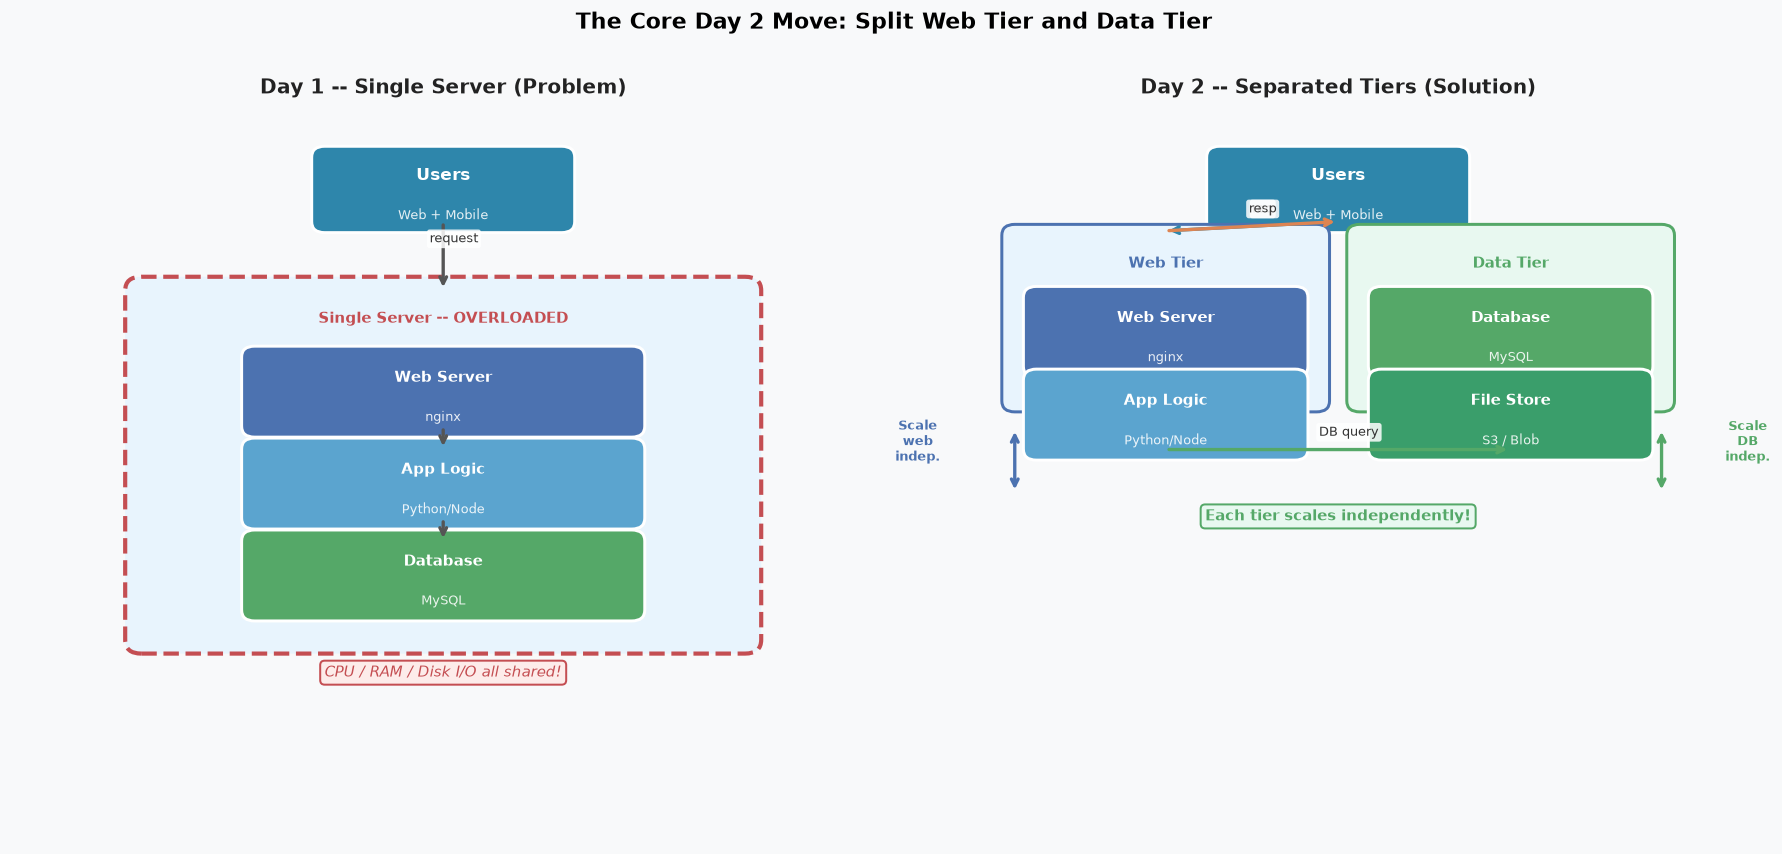

Architecture diagram done.


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
fig.patch.set_facecolor(C_GRAY)

def draw_box(ax, x, y, w, h, label, sublabel='', color=None, fontsize=10):
    if color is None:
        color = C_BLUE
    rect = FancyBboxPatch((x - w/2, y - h/2), w, h,
                          boxstyle='round,pad=0.12', lw=1.8,
                          facecolor=color, edgecolor='white')
    ax.add_patch(rect)
    ax.text(x, y + (0.15 if sublabel else 0), label,
            ha='center', va='center', fontsize=fontsize,
            fontweight='bold', color='white')
    if sublabel:
        ax.text(x, y - 0.28, sublabel, ha='center', va='center',
                fontsize=7.5, color='white', alpha=0.88)

def draw_arrow(ax, x1, y1, x2, y2, label='', color='#555'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=2.0))
    if label:
        mx, my = (x1+x2)/2, (y1+y2)/2
        ax.text(mx + 0.1, my + 0.15, label, ha='center', fontsize=8,
                color='#333',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                          alpha=0.85, lw=0))

# LEFT: single server (Day 1 recap)
ax = axes[0]
ax.set_xlim(0, 8); ax.set_ylim(0, 8)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('Day 1 -- Single Server (Problem)', fontsize=12,
             fontweight='bold', color='#222', pad=8)

draw_box(ax, 4, 7.1, 2.2, 0.7, 'Users', 'Web + Mobile', C_TEAL)
rect = FancyBboxPatch((1.2, 2.2), 5.6, 3.8, boxstyle='round,pad=0.15',
                      lw=2.5, facecolor='#E8F4FD', edgecolor=C_RED, linestyle='--')
ax.add_patch(rect)
ax.text(4, 5.65, 'Single Server -- OVERLOADED', ha='center',
        fontsize=9, fontweight='bold', color=C_RED)
draw_box(ax, 4, 4.9, 3.5, 0.75, 'Web Server',  'nginx',        C_BLUE,   9)
draw_box(ax, 4, 3.9, 3.5, 0.75, 'App Logic',   'Python/Node',  '#5BA4CF',9)
draw_box(ax, 4, 2.9, 3.5, 0.75, 'Database',    'MySQL',        C_GREEN,  9)
draw_arrow(ax, 4, 6.75, 4, 6.0, 'request')
draw_arrow(ax, 4, 4.52, 4, 4.27)
draw_arrow(ax, 4, 3.52, 4, 3.27)
ax.text(4, 1.8, 'CPU / RAM / Disk I/O all shared!', ha='center',
        fontsize=9, color=C_RED, fontstyle='italic',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#FDECEA',
                  edgecolor=C_RED, lw=1.2))

# RIGHT: separated tiers (Day 2)
ax = axes[1]
ax.set_xlim(0, 8); ax.set_ylim(0, 8)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('Day 2 -- Separated Tiers (Solution)', fontsize=12,
             fontweight='bold', color='#222', pad=8)

draw_box(ax, 4, 7.1, 2.2, 0.7, 'Users', 'Web + Mobile', C_TEAL)

rect2 = FancyBboxPatch((1.0, 4.8), 2.8, 1.8, boxstyle='round,pad=0.12',
                        lw=1.8, facecolor='#E8F4FD', edgecolor=C_BLUE)
ax.add_patch(rect2)
ax.text(2.4, 6.25, 'Web Tier', ha='center', fontsize=9,
        fontweight='bold', color=C_BLUE)
draw_box(ax, 2.4, 5.55, 2.4, 0.75, 'Web Server', 'nginx',        C_BLUE,   9)
draw_box(ax, 2.4, 4.65, 2.4, 0.75, 'App Logic',  'Python/Node',  '#5BA4CF',9)

rect3 = FancyBboxPatch((4.2, 4.8), 2.8, 1.8, boxstyle='round,pad=0.12',
                        lw=1.8, facecolor='#E8F8F0', edgecolor=C_GREEN)
ax.add_patch(rect3)
ax.text(5.6, 6.25, 'Data Tier', ha='center', fontsize=9,
        fontweight='bold', color=C_GREEN)
draw_box(ax, 5.6, 5.55, 2.4, 0.75, 'Database',  'MySQL',    C_GREEN,  9)
draw_box(ax, 5.6, 4.65, 2.4, 0.75, 'File Store','S3 / Blob','#3A9E6B',9)

draw_arrow(ax, 4, 6.75, 2.4, 6.65, 'req',      C_TEAL)
draw_arrow(ax, 2.4, 4.27, 5.6, 4.27,'DB query', C_GREEN)
draw_arrow(ax, 2.4, 6.65, 4, 6.75,  'resp',     C_ORANGE)

ax.annotate('', xy=(1.0, 3.8), xytext=(1.0, 4.5),
            arrowprops=dict(arrowstyle='<->', color=C_BLUE, lw=2))
ax.text(0.1, 4.15, 'Scale\nweb\nindep.', ha='center', fontsize=7.5,
        color=C_BLUE, fontweight='bold')

ax.annotate('', xy=(7.0, 3.8), xytext=(7.0, 4.5),
            arrowprops=dict(arrowstyle='<->', color=C_GREEN, lw=2))
ax.text(7.8, 4.15, 'Scale\nDB\nindep.', ha='center', fontsize=7.5,
        color=C_GREEN, fontweight='bold')

ax.text(4, 3.5, 'Each tier scales independently!', ha='center',
        fontsize=9, color=C_GREEN, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#E8F8F0',
                  edgecolor=C_GREEN, lw=1.2))

plt.suptitle('The Core Day 2 Move: Split Web Tier and Data Tier',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/tmp/sd_day2_architecture.png', dpi=130, bbox_inches='tight')
plt.show()
print("Architecture diagram done.")


### What this diagram shows
The **core architectural move of Day 2**: splitting one overloaded box into two independent servers.

- **Left panel (the problem)**: the single server from Day 1 outlined in red. All three components -- web server, app logic, database -- compete for the same CPU, RAM, and disk I/O.
- **Right panel (the solution)**: web tier and data tier each get their own machine. Double-headed arrows show each tier can now be scaled independently.

**Interview framing**: the question is not "should I separate tiers?" but "at what load does keeping them together become a bottleneck?"


## 2 — Resource Contention: Why Separation Helps

After separation, each tier has its own CPU, RAM, and I/O budget.
No more competition on the same box.


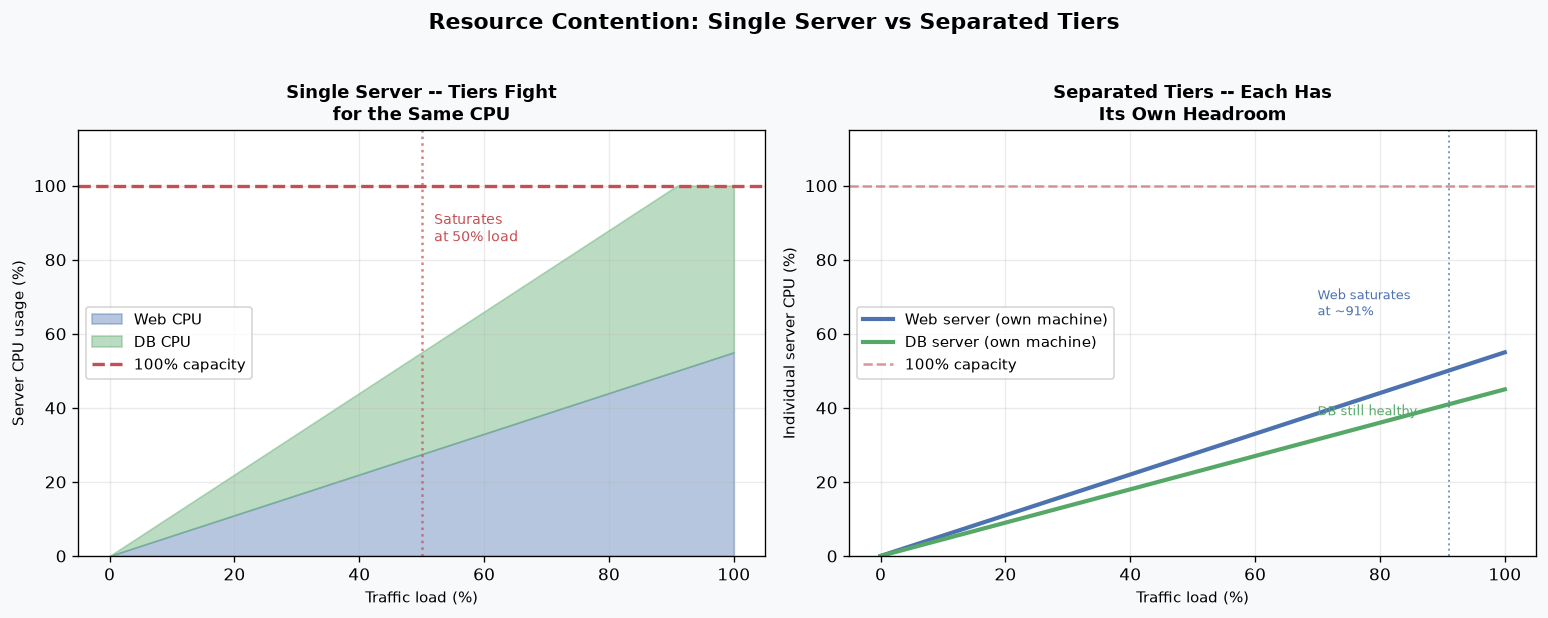

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor(C_GRAY)
load = np.linspace(0, 100, 300)

# Single server: tiers share CPU
ax = axes[0]
cpu_web = np.clip(load * 0.55, 0, 100)
cpu_db  = np.clip(load * 0.55, 0, 100)
total   = np.clip(cpu_web + cpu_db, 0, 100)
ax.fill_between(load, 0,       cpu_web, alpha=0.4, color=C_BLUE,  label='Web CPU')
ax.fill_between(load, cpu_web, total,   alpha=0.4, color=C_GREEN, label='DB CPU')
ax.axhline(100, color=C_RED, lw=2, linestyle='--', label='100% capacity')
ax.axvline(50,  color=C_RED, lw=1.5, linestyle=':', alpha=0.7)
ax.text(52, 85, 'Saturates\nat 50% load', fontsize=8.5, color=C_RED)
ax.set_xlabel('Traffic load (%)', fontsize=9)
ax.set_ylabel('Server CPU usage (%)', fontsize=9)
ax.set_title('Single Server -- Tiers Fight\nfor the Same CPU', fontsize=11, fontweight='bold')
ax.set_ylim(0, 115); ax.legend(fontsize=9); ax.grid(alpha=0.25)

# Separated tiers: each has headroom
ax = axes[1]
web_cpu = np.clip(load * 0.55, 0, 100)
db_cpu  = np.clip(load * 0.45, 0, 100)
ax.plot(load, web_cpu, color=C_BLUE,  lw=2.5, label='Web server (own machine)')
ax.plot(load, db_cpu,  color=C_GREEN, lw=2.5, label='DB server (own machine)')
ax.axhline(100, color=C_RED, lw=1.5, linestyle='--', alpha=0.6, label='100% capacity')
ax.axvline(91,  color=C_BLUE,  lw=1.2, linestyle=':', alpha=0.7)
ax.text(70, 65, 'Web saturates\nat ~91%', fontsize=8, color=C_BLUE)
ax.text(70, 38, 'DB still healthy', fontsize=8, color=C_GREEN)
ax.set_xlabel('Traffic load (%)', fontsize=9)
ax.set_ylabel('Individual server CPU (%)', fontsize=9)
ax.set_title('Separated Tiers -- Each Has\nIts Own Headroom', fontsize=11, fontweight='bold')
ax.set_ylim(0, 115); ax.legend(fontsize=9); ax.grid(alpha=0.25)

plt.suptitle('Resource Contention: Single Server vs Separated Tiers',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/tmp/sd_day2_contention.png', dpi=130, bbox_inches='tight')
plt.show()


### What these charts show
A direct visualisation of **resource contention** -- what happens inside the CPU when two tiers share a machine.

- **Left chart**: web CPU and DB CPU add up to a shared budget. At 50% traffic the machine saturates.
- **Right chart**: separated tiers each have their own 0-100% axis. The web server hits its ceiling at ~91% traffic; the DB machine is still at ~45%.

**Key number**: separation roughly doubles the traffic you can handle before any machine saturates.


### What these charts show
A direct visualisation of **resource contention** -- what happens inside the CPU when two tiers share a machine.

- **Left chart**: web CPU and DB CPU add up to a shared budget. At 50% traffic the machine saturates. Neither tier is at fault -- they share a ceiling.
- **Right chart**: with separated tiers, each machine has its own 0-100% axis. The web server hits its ceiling at ~91% traffic; the DB machine is still at ~45%. You can add a second web server without touching the database at all.

**Key number**: separation roughly doubles the traffic you can handle before any machine saturates, for the cost of one extra server.


### What these charts show
A direct visualisation of **resource contention** -- what happens inside the CPU when two tiers share a machine.

- **Left chart**: web CPU and DB CPU add up to a shared budget. At 50% traffic the machine saturates. Neither tier is at fault -- they share a ceiling.
- **Right chart**: with separated tiers, each machine has its own 0-100% axis. The web server hits its ceiling at ~91% traffic; the DB machine is still at ~45%. You can add a second web server without touching the database at all.

**Key number**: separation roughly doubles the traffic you can handle before any machine saturates, for the cost of one extra server.


### What these charts show
A direct visualisation of **resource contention** -- what happens inside the CPU when two tiers share a machine.

- **Left chart**: the stacked fill shows web CPU and DB CPU adding up to a shared budget. At 50% traffic the machine saturates. Neither tier is at fault -- they share a ceiling.
- **Right chart**: with separated tiers, each machine has its own 0-100% axis. The web server hits its ceiling at ~91% traffic; the DB machine is still at ~45%. You can add a second web server without touching the database at all.

**Key number**: separation roughly doubles the traffic you can handle before any machine saturates, for the cost of one extra server.


### What these charts show
A direct visualisation of **resource contention** -- what happens inside the CPU when two tiers share a machine.

- **Left chart**: web CPU and DB CPU add up to a shared budget. At 50% traffic the machine saturates. Neither tier is at fault -- they share a ceiling.
- **Right chart**: with separated tiers, each machine has its own 0-100% axis. The web server hits its ceiling at ~91% traffic; the DB machine is still at ~45%. You can add a second web server without touching the database at all.

**Key number**: separation roughly doubles the traffic you can handle before any machine saturates, for the cost of one extra server.


### What these charts show
A direct visualisation of **resource contention** — what happens inside the CPU when two tiers share a machine.

- **Left chart**: the stacked fill shows web CPU and DB CPU adding up to a shared budget. At 50% traffic the combined load saturates the machine. Neither tier is "at fault" — they just share a ceiling.
- **Right chart**: with separated tiers, each machine has its own 0–100% axis. The web server hits its ceiling at ~91% traffic; the DB machine is still at ~45%. You can add a second web server without touching the database at all.

**Key number**: separation roughly doubles the traffic you can handle before any single machine saturates, for the cost of one extra server.


### What these charts show
A direct visualisation of **resource contention** — what happens inside the CPU when two tiers share a machine.

- **Left chart**: the stacked fill shows web CPU and DB CPU adding up to a shared budget. At 50% traffic the combined load saturates the machine. Neither tier is "at fault" — they just share a ceiling.
- **Right chart**: with separated tiers, each machine has its own 0–100% axis. The web server hits its ceiling at ~91% traffic; the DB machine is still at ~45%. You can add a second web server without touching the database at all.

**Key number**: separation roughly doubles the traffic you can handle before any single machine saturates, for the cost of one extra server.


### What these charts show
A direct visualisation of **resource contention** — what happens inside the CPU when two tiers share a machine.

- **Left chart**: the stacked fill shows web CPU and DB CPU adding up to a shared budget. At 50% traffic the combined load saturates the machine. Neither tier is "at fault" — they just share a ceiling.
- **Right chart**: with separated tiers, each machine has its own 0–100% axis. The web server hits its ceiling at ~91% traffic; the DB machine is still at ~45%. You can add a second web server without touching the database at all.

**Key number**: separation roughly doubles the traffic you can handle before any single machine saturates, for the cost of one extra server.


### What these charts show
A direct visualisation of **resource contention** — what actually happens inside the CPU when two tiers share a machine.

- **Left chart**: the stacked fill shows web CPU and DB CPU adding up to a shared budget. At 50% traffic the combined load saturates the machine. Neither tier is "at fault" — they just share a ceiling.
- **Right chart**: with separated tiers, each machine has its own 0–100% axis. The web server hits its ceiling at ~91% traffic; the DB machine is still at ~45%. You can add a second web server without touching the database at all.

**Key number to remember**: separation roughly doubles the traffic you can handle before any single machine saturates, for the cost of one extra server.


### What these charts show
A direct visualisation of **resource contention** — what actually happens inside the CPU when two tiers share a machine.

- **Left chart**: the stacked fill shows that web CPU and DB CPU add up to a shared budget. At 50% traffic the combined load saturates the machine. Neither tier is "at fault" — they just share a ceiling.
- **Right chart**: with separated tiers, each machine has its own 0–100% axis. The web server hits its ceiling at ~91% traffic; the DB machine is still at ~45%. You can now add a second web server without touching the database at all.

**Key number to remember**: separation roughly doubles the traffic you can handle before any single machine saturates, for the cost of one extra server.


## 3 — Which Database? SQL vs NoSQL

Once you have a dedicated database server, the second decision is:
**what kind of database runs on it?**

### Relational (SQL)
- Data in **tables with rows and columns**, fixed schema
- Relationships via foreign keys; queries via SQL joins
- ACID transactions — Atomicity, Consistency, Isolation, Durability
- Examples: MySQL, PostgreSQL, SQLite

### Non-Relational (NoSQL)
- Documents, key-value pairs, wide columns, or graphs
- Schema-flexible — each record can differ
- Built for horizontal scale and high write throughput
- Examples: MongoDB (document), Redis (key-value), Cassandra (wide-column), Neo4j (graph)

**Four signals that point to NoSQL:**
- Application requires super-low latency
- Data is unstructured or non-relational
- Only need to serialize/deserialize (JSON, YAML)
- Need to store a massive amount of data


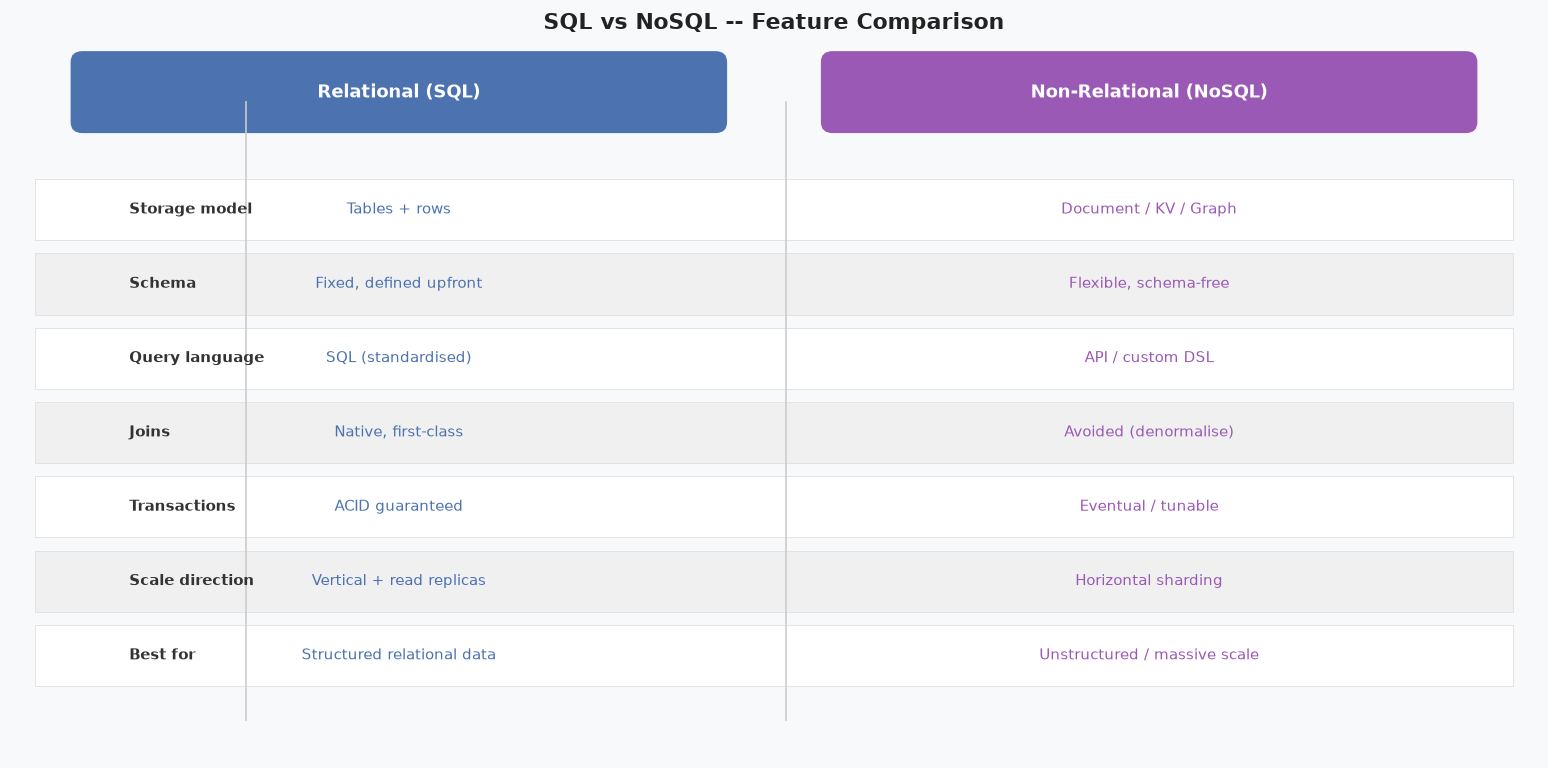

In [4]:
fig, ax = plt.subplots(figsize=(13, 6.5))
ax.set_xlim(0, 13); ax.set_ylim(0, 6.5)
ax.axis('off')
ax.set_facecolor(C_GRAY)
fig.patch.set_facecolor(C_GRAY)

for x, label, color in [(3.3, 'Relational (SQL)', C_BLUE),
                         (9.7, 'Non-Relational (NoSQL)', C_PURPLE)]:
    rect = FancyBboxPatch((x - 2.7, 5.8), 5.4, 0.55,
                          boxstyle='round,pad=0.1', facecolor=color,
                          edgecolor='white', lw=0)
    ax.add_patch(rect)
    ax.text(x, 6.07, label, ha='center', va='center', fontsize=11,
            fontweight='bold', color='white')

rows = [
    ('Storage model',   'Tables + rows',             'Document / KV / Graph'),
    ('Schema',          'Fixed, defined upfront',     'Flexible, schema-free'),
    ('Query language',  'SQL (standardised)',         'API / custom DSL'),
    ('Joins',           'Native, first-class',        'Avoided (denormalise)'),
    ('Transactions',    'ACID guaranteed',            'Eventual / tunable'),
    ('Scale direction', 'Vertical + read replicas',   'Horizontal sharding'),
    ('Best for',        'Structured relational data', 'Unstructured / massive scale'),
]

for i, (prop, sql_val, nosql_val) in enumerate(rows):
    y = 5.0 - i * 0.68
    bg = '#FFFFFF' if i % 2 == 0 else '#F0F0F0'
    rect = FancyBboxPatch((0.2, y - 0.28), 12.6, 0.56,
                          boxstyle='square,pad=0', facecolor=bg,
                          edgecolor='#E0E0E0', lw=0.5)
    ax.add_patch(rect)
    ax.text(1.0, y, prop,      ha='left',   va='center', fontsize=9,
            fontweight='bold', color='#333')
    ax.text(3.3, y, sql_val,   ha='center', va='center', fontsize=9, color=C_BLUE)
    ax.text(9.7, y, nosql_val, ha='center', va='center', fontsize=9, color=C_PURPLE)

for xv in [2.0, 6.6]:
    ax.axvline(xv, ymin=0.05, ymax=0.92, color='#CCC', lw=1)

ax.set_title('SQL vs NoSQL -- Feature Comparison', fontsize=13,
             fontweight='bold', color='#222', pad=10)
plt.tight_layout()
plt.savefig('/tmp/sd_day2_comparison_table.png', dpi=130, bbox_inches='tight')
plt.show()


### What this table shows
A structured comparison of **SQL vs NoSQL across seven dimensions** relevant to system design decisions.

Read each row as a trade-off axis:
- **Schema**: SQL's fixed schema enforces integrity; NoSQL's flexibility handles evolving requirements.
- **Joins**: SQL joins are powerful; NoSQL avoids them by denormalising.
- **Transactions**: ACID is the primary reason to choose SQL for financial or booking systems.
- **Scale direction**: SQL scales vertically; NoSQL scales horizontally via sharding.

**Interview tip**: examiners want trade-offs, not product names.


## 4 — When to Choose NoSQL: Four Signals Visualised


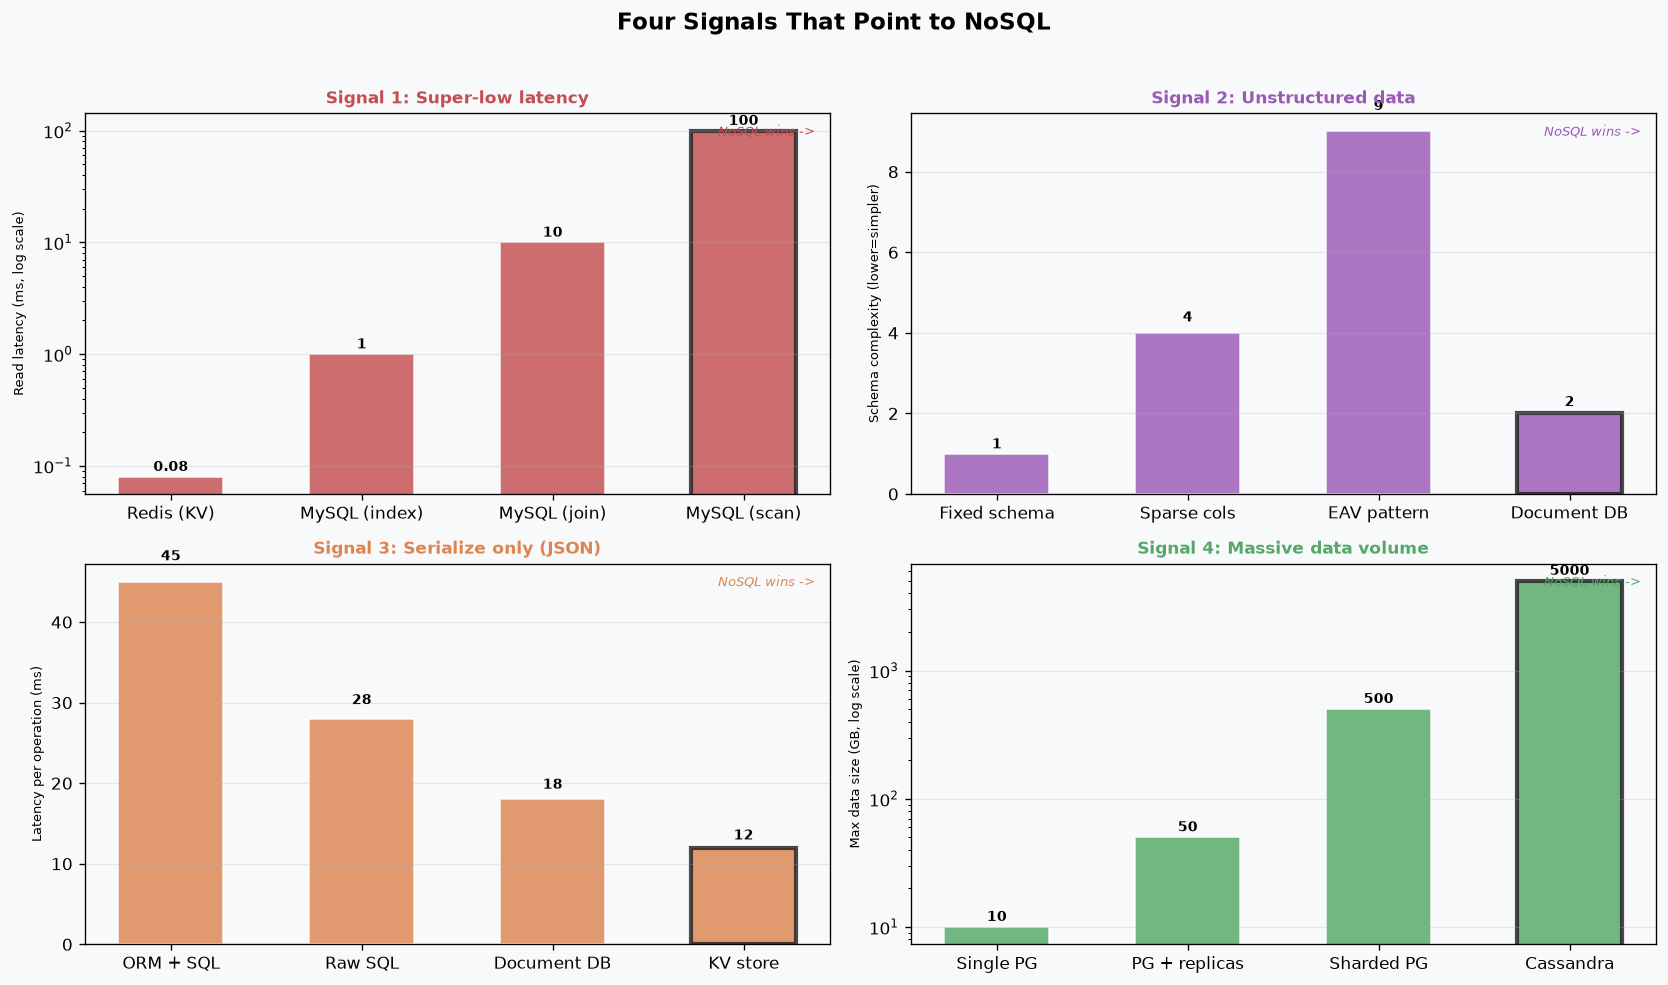

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.patch.set_facecolor(C_GRAY)
plt.suptitle('Four Signals That Point to NoSQL', fontsize=14,
             fontweight='bold', y=1.02)

panels = [
    ('Signal 1: Super-low latency',
     [0.08, 1, 10, 100],
     ['Redis (KV)', 'MySQL (index)', 'MySQL (join)', 'MySQL (scan)'],
     'Read latency (ms, log scale)', C_RED),
    ('Signal 2: Unstructured data',
     [1, 4, 9, 2],
     ['Fixed schema', 'Sparse cols', 'EAV pattern', 'Document DB'],
     'Schema complexity (lower=simpler)', C_PURPLE),
    ('Signal 3: Serialize only (JSON)',
     [45, 28, 18, 12],
     ['ORM + SQL', 'Raw SQL', 'Document DB', 'KV store'],
     'Latency per operation (ms)', C_ORANGE),
    ('Signal 4: Massive data volume',
     [10, 50, 500, 5000],
     ['Single PG', 'PG + replicas', 'Sharded PG', 'Cassandra'],
     'Max data size (GB, log scale)', C_GREEN),
]

for ax, (title, vals, xlabels, ylabel, color) in zip(axes.flat, panels):
    ax.set_facecolor(C_GRAY)
    bars = ax.bar(xlabels, vals, color=[color]*len(vals), alpha=0.82,
                  edgecolor='white', width=0.55)
    bars[-1].set_edgecolor('#222'); bars[-1].set_linewidth(2.5)
    ax.set_ylabel(ylabel, fontsize=8)
    ax.set_title(title, fontsize=10, fontweight='bold', color=color)
    ax.grid(axis='y', alpha=0.25)
    if 'log' in ylabel:
        ax.set_yscale('log')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.05,
                str(val), ha='center', va='bottom',
                fontsize=8.5, fontweight='bold')
    ax.text(0.98, 0.97, 'NoSQL wins ->', ha='right', va='top',
            transform=ax.transAxes, fontsize=7.5, color=color,
            fontstyle='italic')

plt.tight_layout()
plt.savefig('/tmp/sd_day2_nosql_signals.png', dpi=130, bbox_inches='tight')
plt.show()


### What these charts show
Each panel maps one of the **four concrete NoSQL signals** to a measurable comparison.

- **Top-left (latency)**: Redis at 0.08 ms vs MySQL at 1-100 ms. Sub-millisecond SLAs need a KV store.
- **Top-right (unstructured)**: variable-shape records are simpler in a document store.
- **Bottom-left (serialize only)**: whole-object storage without joins favours document/KV stores.
- **Bottom-right (massive volume)**: distributed wide-column stores scale to petabytes linearly.

The **highlighted final bar** in each panel is the NoSQL winner for that signal.


### What these charts show
Each panel maps one of the **four concrete NoSQL signals** to a measurable comparison.

- **Top-left (latency)**: Redis at 0.08 ms vs MySQL at 1-100 ms. When your SLA demands sub-millisecond responses, a relational DB cannot meet it regardless of indexing.
- **Top-right (unstructured)**: variable-shape records in SQL require complex EAV patterns or NULLs. A document store keeps schema complexity minimal.
- **Bottom-left (serialize only)**: if your app just stores and retrieves whole objects without joins, every ORM layer is pure overhead.
- **Bottom-right (massive volume)**: single Postgres maxes out around 10-50 GB. A distributed wide-column store scales to petabytes by adding nodes.

The **highlighted final bar** in each panel is the NoSQL option that wins for that signal.


### What these charts show
Each panel maps one of the **four concrete NoSQL signals** to a measurable comparison.

- **Top-left (latency)**: Redis at 0.08 ms vs MySQL at 1-100 ms. When your SLA demands sub-millisecond responses, a relational DB cannot meet it regardless of indexing.
- **Top-right (unstructured)**: storing variable-shape records in SQL requires complex EAV patterns or NULLs. A document store keeps schema complexity minimal.
- **Bottom-left (serialize only)**: if your app just stores and retrieves whole objects without joins, every ORM layer is pure overhead.
- **Bottom-right (massive volume)**: single Postgres maxes out around 10-50 GB. A distributed wide-column store scales to petabytes by adding nodes.

The **highlighted final bar** in each panel is the NoSQL option that wins for that signal.


### What these charts show
Each panel maps one of the **four concrete NoSQL signals** to a measurable comparison.

- **Top-left (latency)**: Redis at 0.08 ms vs MySQL at 1-100 ms. When your SLA demands sub-millisecond responses, a relational DB cannot meet it regardless of indexing.
- **Top-right (unstructured)**: storing variable-shape records in SQL requires complex EAV patterns or NULLs. A document store keeps schema complexity minimal.
- **Bottom-left (serialize only)**: if your app just stores and retrieves whole objects without joins, every ORM layer is pure overhead.
- **Bottom-right (massive volume)**: single Postgres maxes out around 10-50 GB. A distributed wide-column store scales to petabytes by adding nodes.

The **highlighted final bar** in each panel is the NoSQL option that wins for that signal.


### What these charts show
Each panel maps one of the **four concrete NoSQL signals** to a measurable comparison.

- **Top-left (latency)**: Redis at 0.08 ms vs MySQL at 1-100 ms. When your SLA demands sub-millisecond responses, a relational DB cannot meet it regardless of indexing.
- **Top-right (unstructured)**: storing variable-shape records in SQL requires complex EAV patterns or NULLs. A document store keeps schema complexity minimal.
- **Bottom-left (serialize only)**: if your app just stores and retrieves whole objects without joins, every ORM layer is pure overhead.
- **Bottom-right (massive volume)**: single Postgres maxes out around 10-50 GB before ops complexity explodes. A distributed wide-column store scales to petabytes by adding nodes.

The **highlighted final bar** in each panel is the NoSQL option that wins for that signal.


### What these charts show
Each panel maps one of the **four concrete NoSQL signals** to a measurable comparison.

- **Top-left (latency)**: Redis at 0.08 ms vs MySQL at 1–100 ms. When your SLA demands sub-millisecond responses (gaming, rate limiting, real-time bidding), a relational DB cannot meet it regardless of indexing.
- **Top-right (unstructured data)**: storing variable-shape records in SQL requires complex EAV patterns or NULLs everywhere. A document store keeps schema complexity minimal.
- **Bottom-left (serialize only)**: if your app just stores and retrieves whole objects without joins or aggregations, every ORM layer and SQL round-trip is pure overhead.
- **Bottom-right (massive volume)**: single Postgres maxes out around 10–50 GB before ops complexity explodes. A distributed wide-column store scales to petabytes by adding nodes.

The **highlighted final bar** in each panel is the NoSQL option that wins for that signal.


### What these charts show
Each panel maps one of the **four concrete NoSQL signals** to a measurable comparison.

- **Top-left (latency)**: Redis at 0.08 ms vs MySQL at 1–100 ms. When your SLA demands sub-millisecond responses (gaming, rate limiting, real-time bidding), a relational DB cannot meet it regardless of indexing.
- **Top-right (unstructured data)**: storing variable-shape records in SQL requires complex EAV patterns or NULLs everywhere — both score high on complexity. A document store keeps it simple.
- **Bottom-left (serialize only)**: if your app just stores and retrieves whole objects without joins or aggregations, every ORM layer and SQL round-trip is pure overhead.
- **Bottom-right (massive volume)**: single Postgres maxes out around 10–50 GB before ops complexity explodes. A distributed wide-column store scales to petabytes by adding nodes.

The **highlighted final bar** in each panel is the NoSQL option that wins for that signal.


### What these charts show
Each panel maps one of the **four concrete NoSQL signals** to a measurable comparison.

- **Top-left (latency)**: Redis at 0.08 ms vs MySQL at 1–100 ms. When your SLA demands sub-millisecond responses (gaming, rate limiting, real-time bidding), a relational DB cannot meet it regardless of indexing.
- **Top-right (unstructured data)**: storing variable-shape records in SQL requires complex EAV patterns or NULLs everywhere — both score high on complexity. A document store keeps it simple.
- **Bottom-left (serialize only)**: if your app just stores and retrieves whole objects without joins or aggregations, every ORM layer and SQL round-trip is pure overhead.
- **Bottom-right (massive volume)**: single Postgres maxes out around 10–50 GB before ops complexity explodes. A distributed wide-column store scales to petabytes by adding nodes.

The **highlighted final bar** in each panel is the NoSQL option that wins for that signal.


### What these charts show
Each panel maps one of the **four concrete NoSQL signals** to a measurable comparison.

- **Top-left (latency)**: Redis at 0.08 ms vs MySQL at 1–100 ms. When your SLA demands sub-millisecond responses (gaming, rate limiting, real-time bidding), a relational DB cannot meet it regardless of indexing.
- **Top-right (unstructured data)**: storing variable-shape records in SQL requires complex EAV patterns or NULLs everywhere. A document store keeps schema complexity at 2/16.
- **Bottom-left (serialize only)**: if your app just stores and retrieves whole objects without aggregations or joins, every ORM layer and SQL round-trip is pure overhead.
- **Bottom-right (massive volume)**: single Postgres maxes out around 10–50 GB before ops complexity explodes. A distributed wide-column store scales to petabytes by adding nodes.

The **highlighted final bar** in each panel is the NoSQL option that wins for that signal.


### What these charts show
Each panel maps one of the **four concrete NoSQL signals** to a measurable comparison.

- **Top-left (latency)**: Redis at 0.08 ms vs MySQL at 1–100 ms. When your SLA demands sub-millisecond responses (gaming sessions, rate limiting, real-time bidding), a relational DB cannot meet it regardless of indexing.
- **Top-right (unstructured data)**: storing records with variable shape in SQL requires complex EAV patterns or columns full of NULLs — both score high on complexity. A document store keeps it simple.
- **Bottom-left (serialize only)**: if your app just stores and retrieves whole objects without aggregations or joins, every ORM layer and SQL round-trip is pure overhead.
- **Bottom-right (massive volume)**: single Postgres maxes out around 10–50 GB before ops complexity explodes. A distributed wide-column store scales to petabytes by adding nodes linearly.

The **highlighted final bar** in each panel is the NoSQL option that wins for that specific signal.


## 5 — Four NoSQL Storage Models

NoSQL is not one thing — it is four distinct storage models, each built for a different access pattern.


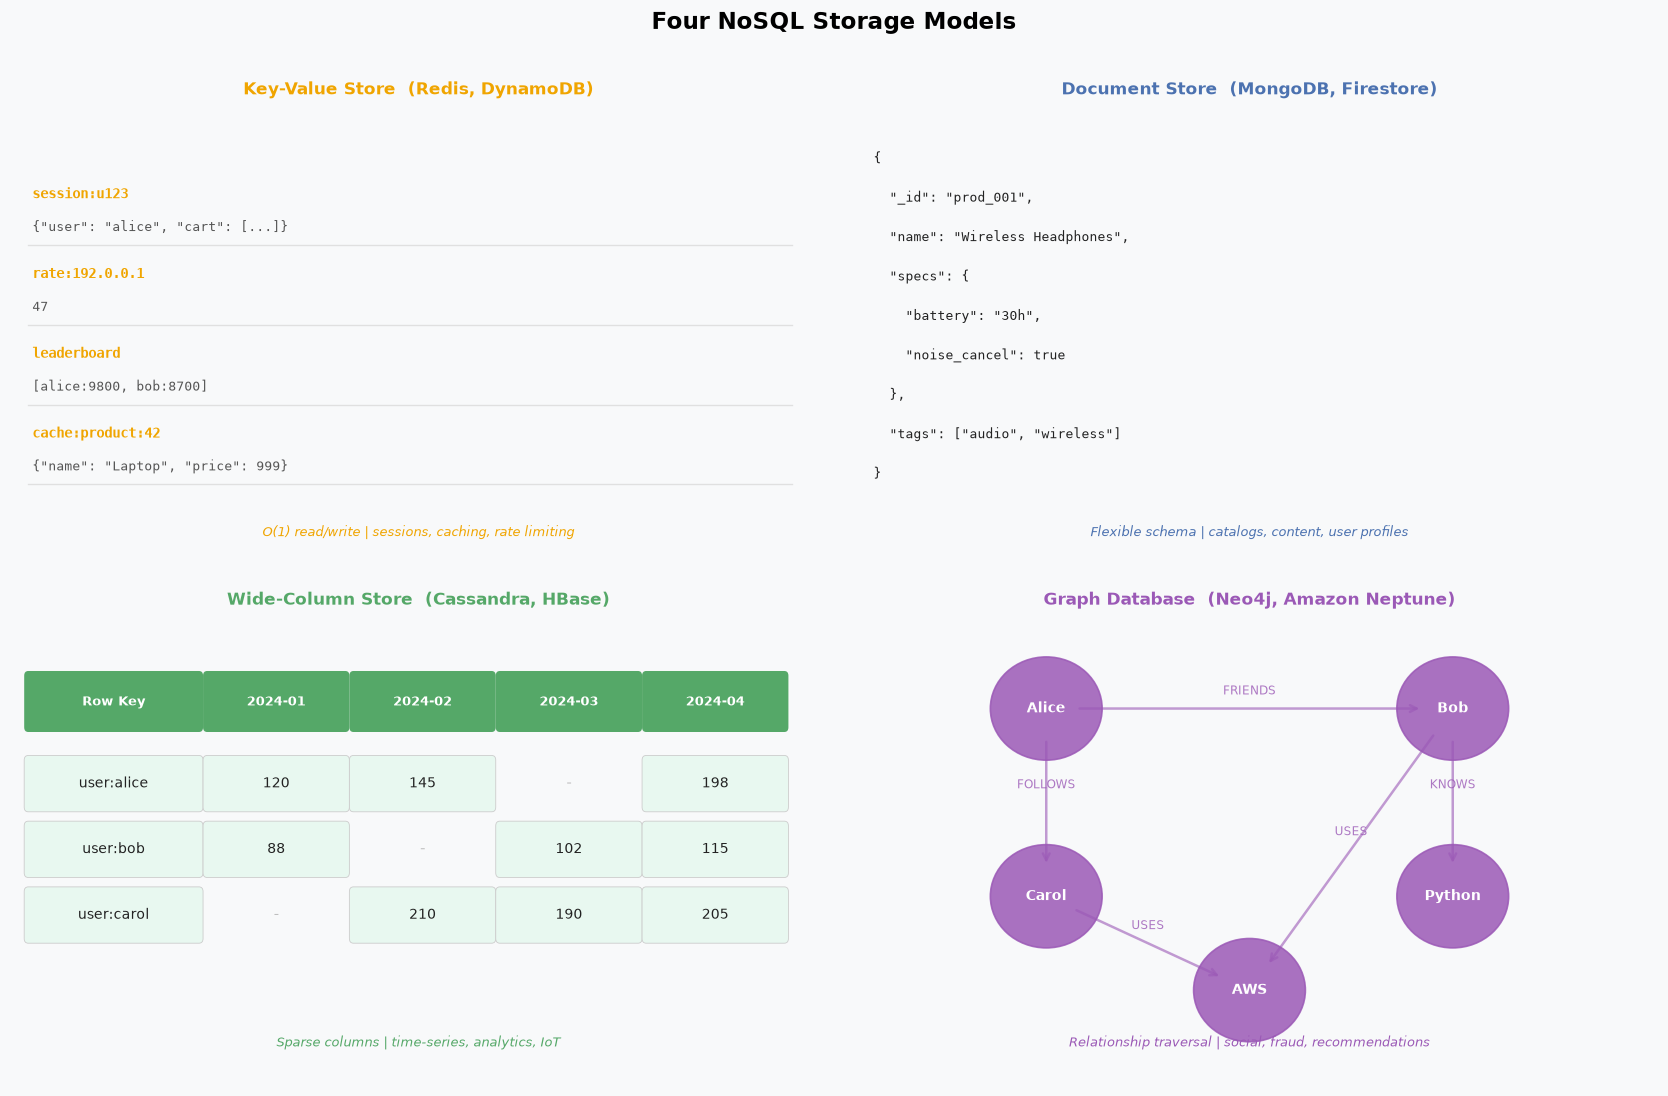

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.patch.set_facecolor(C_GRAY)
plt.suptitle('Four NoSQL Storage Models', fontsize=14, fontweight='bold', y=1.01)

# Key-Value Store
ax = axes[0][0]
ax.set_xlim(0, 8); ax.set_ylim(0, 5)
ax.axis('off'); ax.set_facecolor('#FFF8E7')
ax.set_title('Key-Value Store  (Redis, DynamoDB)', fontsize=10,
             fontweight='bold', color=C_GOLD)
kv_pairs = [
    ('session:u123',    '{"user": "alice", "cart": [...]}'),
    ('rate:192.0.0.1',  '47'),
    ('leaderboard',     '[alice:9800, bob:8700]'),
    ('cache:product:42','{"name": "Laptop", "price": 999}'),
]
for i, (k, v) in enumerate(kv_pairs):
    y = 4.0 - i * 0.85
    ax.text(0.2, y,       k, fontsize=8.5, color=C_GOLD,
            fontfamily='monospace', fontweight='bold')
    ax.text(0.2, y - 0.35, v, fontsize=7.5, color='#555',
            fontfamily='monospace')
    ax.axhline(y - 0.5, xmin=0.02, xmax=0.96, color='#E0E0E0', lw=0.8)
ax.text(4, 0.4, 'O(1) read/write | sessions, caching, rate limiting',
        ha='center', fontsize=8, color=C_GOLD, fontstyle='italic')

# Document Store
ax = axes[0][1]
ax.set_xlim(0, 8); ax.set_ylim(0, 5)
ax.axis('off'); ax.set_facecolor('#F0F4FF')
ax.set_title('Document Store  (MongoDB, Firestore)', fontsize=10,
             fontweight='bold', color=C_BLUE)
doc_lines = [
    '{',
    '  "_id": "prod_001",',
    '  "name": "Wireless Headphones",',
    '  "specs": {',
    '    "battery": "30h",',
    '    "noise_cancel": true',
    '  },',
    '  "tags": ["audio", "wireless"]',
    '}',
]
for i, line in enumerate(doc_lines):
    ax.text(0.3, 4.5 - i * 0.42, line, fontsize=8, color='#222',
            fontfamily='monospace', va='top')
ax.text(4, 0.4, 'Flexible schema | catalogs, content, user profiles',
        ha='center', fontsize=8, color=C_BLUE, fontstyle='italic')

# Wide-Column Store
ax = axes[1][0]
ax.set_xlim(0, 10); ax.set_ylim(0, 5)
ax.axis('off'); ax.set_facecolor('#F0FFF4')
ax.set_title('Wide-Column Store  (Cassandra, HBase)', fontsize=10,
             fontweight='bold', color=C_GREEN)
headers = ['Row Key', '2024-01', '2024-02', '2024-03', '2024-04']
widths  = [2.2, 1.8, 1.8, 1.8, 1.8]
xs = [0.2]
for w in widths[:-1]:
    xs.append(xs[-1] + w)
for j, (h, x, w) in enumerate(zip(headers, xs, widths)):
    r = FancyBboxPatch((x, 3.8), w - 0.1, 0.55, boxstyle='round,pad=0.05',
                        facecolor=C_GREEN, edgecolor='white', lw=0)
    ax.add_patch(r)
    ax.text(x + w/2 - 0.05, 4.07, h, ha='center', va='center',
            fontsize=8, fontweight='bold', color='white')
data_rows = [
    ('user:alice', '120', '145', None,  '198'),
    ('user:bob',   '88',  None,  '102', '115'),
    ('user:carol', None,  '210', '190', '205'),
]
for i, row in enumerate(data_rows):
    y = 3.2 - i * 0.7
    for j, (val, x, w) in enumerate(zip(row, xs, widths)):
        if val is None:
            ax.text(x + w/2 - 0.05, y, '-', ha='center', va='center',
                    fontsize=9, color='#BBB')
        else:
            r2 = FancyBboxPatch((x, y - 0.25), w - 0.1, 0.5,
                                 boxstyle='round,pad=0.05',
                                 facecolor='#E8F8F0', edgecolor='#CCC', lw=0.5)
            ax.add_patch(r2)
            ax.text(x + w/2 - 0.05, y, val, ha='center', va='center',
                    fontsize=8.5, color='#222')
ax.text(5, 0.4, 'Sparse columns | time-series, analytics, IoT',
        ha='center', fontsize=8, color=C_GREEN, fontstyle='italic')

# Graph DB
ax = axes[1][1]
ax.set_xlim(0, 8); ax.set_ylim(0, 5)
ax.axis('off'); ax.set_facecolor('#F9F0FF')
ax.set_title('Graph Database  (Neo4j, Amazon Neptune)', fontsize=10,
             fontweight='bold', color=C_PURPLE)
nodes_g = {'Alice':(2,4), 'Bob':(6,4), 'Carol':(2,2),
           'Python':(6,2), 'AWS':(4,1)}
for name, (x, y) in nodes_g.items():
    circ = plt.Circle((x, y), 0.55, color=C_PURPLE, zorder=3, alpha=0.85)
    ax.add_patch(circ)
    ax.text(x, y, name, ha='center', va='center', fontsize=8.5,
            fontweight='bold', color='white', zorder=4)
graph_edges = [('Alice','Bob','FRIENDS'), ('Alice','Carol','FOLLOWS'),
               ('Bob','Python','KNOWS'),  ('Carol','AWS','USES'),
               ('Bob','AWS','USES')]
for (a, b, lbl) in graph_edges:
    x1, y1 = nodes_g[a]; x2, y2 = nodes_g[b]
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=C_PURPLE, lw=1.5,
                                alpha=0.6, shrinkA=20, shrinkB=20))
    ax.text((x1+x2)/2, (y1+y2)/2 + 0.15, lbl,
            ha='center', fontsize=7, color=C_PURPLE, alpha=0.8)
ax.text(4, 0.4, 'Relationship traversal | social, fraud, recommendations',
        ha='center', fontsize=8, color=C_PURPLE, fontstyle='italic')

plt.tight_layout()
plt.savefig('/tmp/sd_day2_nosql_types.png', dpi=130, bbox_inches='tight')
plt.show()


### What this panel shows
The four NoSQL families, each illustrated with a **real data example**.

- **Key-Value (top-left)**: prefixed keys (`session:`, `rate:`, `cache:`) for namespacing. O(1) lookup in memory.
- **Document (top-right)**: JSON with nested objects and arrays -- impossible to represent cleanly in a single SQL row.
- **Wide-Column (bottom-left)**: sparse table where missing cells are truly absent (not NULL). Efficient for time-series and IoT.
- **Graph (bottom-right)**: O(1) relationship traversal per hop; SQL equivalent requires recursive CTEs.


### What these charts show
A direct visualisation of **resource contention** — what actually happens inside the CPU when two tiers share a machine.

- **Left chart**: the stacked fill shows that web CPU and DB CPU add up. At 50% traffic the combined load saturates the machine. Neither tier is to blame individually — they just share a ceiling.
- **Right chart**: with separated tiers, each machine has its own 0–100% axis. The web server hits its ceiling at ~91% traffic; the DB machine is still at ~45%. You can now add a second web server without touching the database at all.

**Key number to remember**: separation roughly doubles the traffic you can handle before any single machine saturates, for the cost of one extra server.


## 6 — Scaling Profile: SQL vs NoSQL


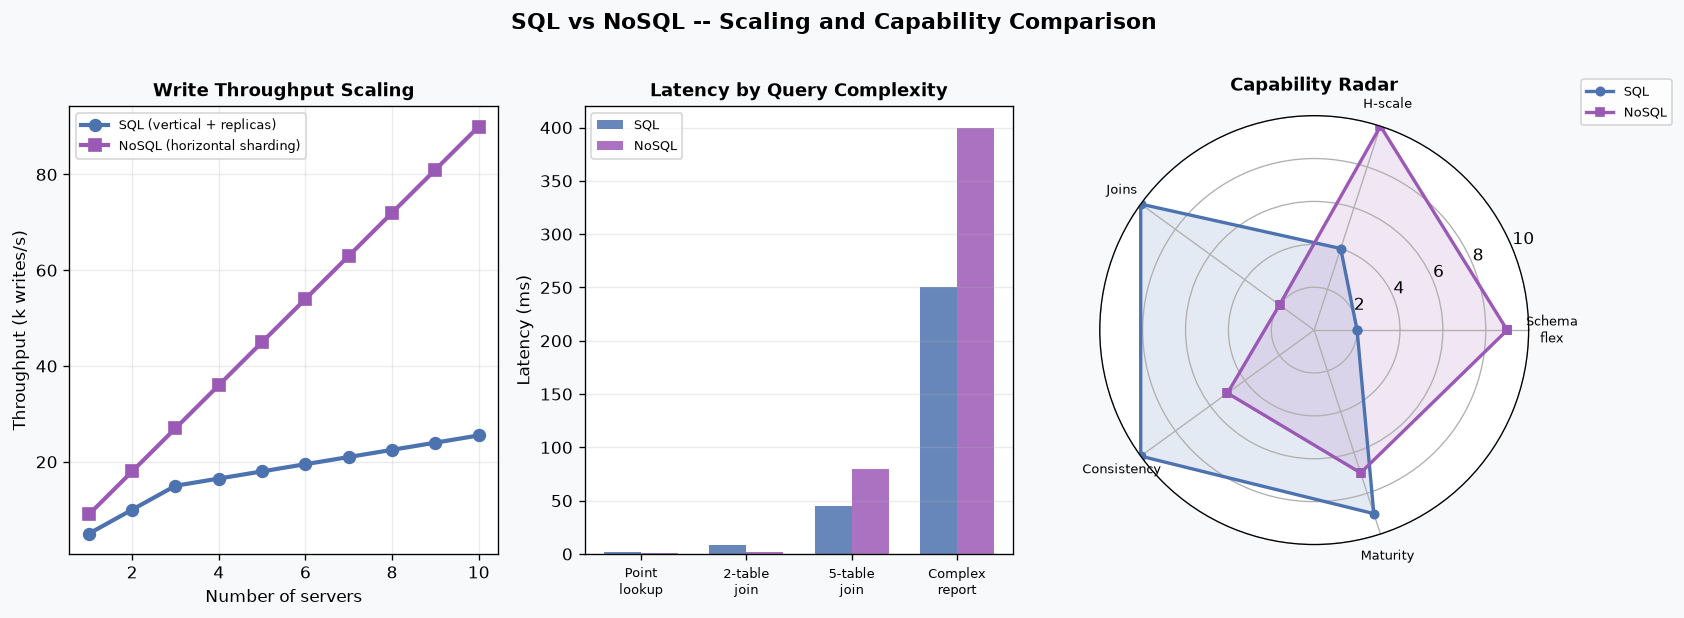

In [7]:
fig = plt.figure(figsize=(14, 5))
fig.patch.set_facecolor(C_GRAY)

# Throughput scaling
ax1 = fig.add_subplot(131)
nodes = np.arange(1, 11)
sql_tput   = np.where(nodes <= 3, nodes * 5000, 3 * 5000 + (nodes - 3) * 1500)
nosql_tput = nodes * 9000
ax1.plot(nodes, sql_tput/1000,   'o-', color=C_BLUE,   lw=2.5, ms=7,
         label='SQL (vertical + replicas)')
ax1.plot(nodes, nosql_tput/1000, 's-', color=C_PURPLE, lw=2.5, ms=7,
         label='NoSQL (horizontal sharding)')
ax1.set_xlabel('Number of servers'); ax1.set_ylabel('Throughput (k writes/s)')
ax1.set_title('Write Throughput Scaling', fontsize=11, fontweight='bold')
ax1.legend(fontsize=8); ax1.grid(alpha=0.25)

# Query latency by complexity
ax2 = fig.add_subplot(132)
query_types   = ['Point\nlookup', '2-table\njoin', '5-table\njoin', 'Complex\nreport']
sql_latency   = [2,   8,  45, 250]
nosql_latency = [0.5, 2,  80, 400]
x = np.arange(len(query_types))
w = 0.35
ax2.bar(x - w/2, sql_latency,   width=w, color=C_BLUE,   alpha=0.85, label='SQL')
ax2.bar(x + w/2, nosql_latency, width=w, color=C_PURPLE, alpha=0.85, label='NoSQL')
ax2.set_xticks(x); ax2.set_xticklabels(query_types, fontsize=8)
ax2.set_ylabel('Latency (ms)')
ax2.set_title('Latency by Query Complexity', fontsize=11, fontweight='bold')
ax2.legend(fontsize=8); ax2.grid(axis='y', alpha=0.25)

# Radar
ax3 = fig.add_subplot(133, polar=True)
categories = ['Schema\nflex', 'H-scale', 'Joins', 'Consistency', 'Maturity']
sql_s   = [2, 4, 10, 10, 9]
nosql_s = [9, 10, 2,  5,  7]
angles  = np.linspace(0, 2*np.pi, len(categories), endpoint=False).tolist()
sql_s   = sql_s   + [sql_s[0]]
nosql_s = nosql_s + [nosql_s[0]]
ang     = angles  + [angles[0]]
ax3.plot(ang, sql_s,   'o-', color=C_BLUE,   lw=2, ms=5, label='SQL')
ax3.fill(ang, sql_s,   alpha=0.15, color=C_BLUE)
ax3.plot(ang, nosql_s, 's-', color=C_PURPLE, lw=2, ms=5, label='NoSQL')
ax3.fill(ang, nosql_s, alpha=0.15, color=C_PURPLE)
ax3.set_xticks(angles)
ax3.set_xticklabels(categories, fontsize=8)
ax3.set_ylim(0, 10)
ax3.set_title('Capability Radar', fontsize=11, fontweight='bold', pad=15)
ax3.legend(fontsize=8, loc='upper right', bbox_to_anchor=(1.35, 1.1))

plt.suptitle('SQL vs NoSQL -- Scaling and Capability Comparison',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/tmp/sd_day2_scaling.png', dpi=130, bbox_inches='tight')
plt.show()


### What these charts show
Three complementary views of SQL vs NoSQL **at scale**.

- **Left (throughput)**: NoSQL sharding keeps write throughput linear; SQL replica coordination adds overhead.
- **Centre (latency)**: SQL wins on complex joins; both are fast for point lookups.
- **Right (radar)**: SQL excels at consistency and joins; NoSQL at horizontal scale and schema flexibility. Most mature systems use both.


### What these charts show
Three complementary views of SQL vs NoSQL **at scale**.

- **Left (throughput)**: SQL write throughput grows slowly after three servers because coordinating replicas adds overhead. NoSQL sharding keeps write throughput linear.
- **Centre (latency by query type)**: for simple point lookups both are fast. For complex joins SQL wins. For extreme-scale analytics, a dedicated data warehouse is better.
- **Right (capability radar)**: SQL is strong on joins, consistency, and maturity. NoSQL is strong on schema flexibility and horizontal scale. The weaknesses are mirror images -- which is why most mature systems use both.


### What these charts show
Three complementary views of SQL vs NoSQL **at scale**.

- **Left (throughput)**: SQL write throughput grows slowly after three servers because coordinating writes across replicas adds overhead. NoSQL sharding keeps write throughput linear.
- **Centre (latency by query type)**: for simple point lookups both are fast. For complex joins SQL wins. For extreme-scale analytics, a dedicated data warehouse is better.
- **Right (capability radar)**: SQL is strong on joins, consistency, and maturity. NoSQL is strong on schema flexibility and horizontal scale. The weaknesses are mirror images -- which is why most mature systems use both.


### What these charts show
Three complementary views of SQL vs NoSQL **at scale**.

- **Left (throughput)**: SQL write throughput grows slowly after three servers because coordinating writes across replicas adds overhead. NoSQL sharding keeps write throughput linear -- more nodes, more writes.
- **Centre (latency by query type)**: for simple point lookups both are fast. For complex multi-table joins SQL wins. For extreme-scale analytics, a dedicated data warehouse is better than either.
- **Right (capability radar)**: SQL is strong on joins, consistency, and maturity. NoSQL is strong on schema flexibility and horizontal scale. The weaknesses are mirror images -- which is why most mature systems use both together.


### What these charts show
Three complementary views of SQL vs NoSQL **at scale**.

- **Left (throughput)**: SQL write throughput grows slowly after three servers because coordinating writes across replicas adds overhead. NoSQL sharding keeps write throughput linear.
- **Centre (latency by query type)**: for simple point lookups both are fast. For complex multi-table joins SQL wins. For extreme-scale analytics, a dedicated data warehouse is better than either.
- **Right (capability radar)**: SQL is strong on joins, consistency, and maturity. NoSQL is strong on schema flexibility and horizontal scale. The weaknesses are mirror images -- which is why most mature systems use both.


### What these charts show
Three complementary views of SQL vs NoSQL **at scale**.

- **Left (throughput)**: SQL write throughput grows slowly after three servers because coordinating writes across replicas adds overhead. NoSQL sharding keeps write throughput linear — more nodes, proportionally more writes.
- **Centre (latency by query type)**: for simple point lookups both approaches are fast. For complex multi-table joins SQL wins (it is built for this). For extreme-scale analytics, neither is ideal — that workload belongs in a data warehouse.
- **Right (capability radar)**: the shape tells the whole story. SQL is strong on joins, consistency, and maturity. NoSQL is strong on schema flexibility and horizontal scale. The weaknesses are mirror images — which is why most mature systems use both.


### What these charts show
Three complementary views of SQL vs NoSQL **at scale**.

- **Left (throughput)**: SQL write throughput grows slowly after three servers because coordinating writes across replicas adds overhead. NoSQL sharding keeps write throughput linear — more nodes, proportionally more writes.
- **Centre (latency by query type)**: for simple point lookups both approaches are fast. For complex multi-table joins SQL wins (it is built for this). For extreme-scale analytics, neither is ideal — that workload belongs in a data warehouse.
- **Right (capability radar)**: the shape tells the whole story. SQL is strong on joins, consistency, and maturity. NoSQL is strong on schema flexibility and horizontal scale. The weaknesses are mirror images — which is why most mature systems use both.


### What these charts show
Three complementary views of SQL vs NoSQL **at scale**.

- **Left (throughput)**: SQL write throughput grows slowly after three servers because coordinating writes across replicas adds overhead. NoSQL sharding keeps write throughput linear — more nodes, proportionally more writes.
- **Centre (latency by query type)**: for simple point lookups both approaches are fast. For complex multi-table joins SQL wins (it is built for this). For extreme-scale analytics, neither is ideal — that workload belongs in a data warehouse.
- **Right (capability radar)**: the shape tells the whole story. SQL is strong on joins, consistency, and maturity. NoSQL is strong on schema flexibility and horizontal scale. The weaknesses are mirror images — which is why most mature systems use both.


### What these charts show
Three complementary views of SQL vs NoSQL **at scale**.

- **Left (throughput)**: SQL write throughput grows slowly after three servers because coordinating writes across replicas adds overhead. NoSQL sharding keeps write throughput linear — more nodes, proportionally more writes.
- **Centre (latency by query type)**: for simple point lookups both approaches are fast. For complex multi-table joins SQL is faster (it is built for this). For analytical reports at extreme scale, neither is ideal — that belongs in a dedicated data warehouse.
- **Right (capability radar)**: the shape tells the whole story. SQL is strong on joins, consistency, and maturity. NoSQL is strong on schema flexibility and horizontal scale. The weaknesses are mirror images — which is why most mature systems use both together.


### What these charts show
Three complementary views of SQL vs NoSQL **at scale**.

- **Left (throughput)**: SQL write throughput grows slowly after three servers because coordinating writes across replicas adds overhead. NoSQL sharding keeps write throughput linear — more nodes means proportionally more writes.
- **Centre (latency by query type)**: for simple point lookups both approaches are fast. For complex multi-table joins SQL is faster (it is built for this). For extremely complex analytical reports neither is ideal — that workload belongs in a dedicated data warehouse.
- **Right (capability radar)**: the shape tells the whole story. SQL is strong on joins, consistency, and ecosystem maturity. NoSQL is strong on schema flexibility and horizontal scale. The weaknesses are mirror images — which is why most mature systems use both together.


## 7 — Key Takeaways

```
Day 2 Principles
================

1. Separate web tier and data tier.
   Each gets its own server. Each scales independently.
   This is the first real architectural decision after Day 1.

2. SQL is the safe default.
   Structured data, joins, transactions, well-understood ops.
   Start here unless you have a specific reason not to.

3. NoSQL is specialised, not universally better.
   Choose it only when you have a clear signal:
     Sub-ms latency       -> Key-Value (Redis)
     Flexible schema      -> Document (MongoDB)
     Petabyte-scale write -> Wide-Column (Cassandra)
     Graph traversal      -> Graph (Neo4j)

4. You can mix both.
   Most real systems: SQL as source of truth +
   a NoSQL/cache layer in front for speed.

5. The bottleneck shifts.
   Day 1: single server CPU.
   Day 2: DB connections and query latency.
   Day 3: what happens when even the separated DB can't keep up.
```

### What Day 3 will cover
**Vertical Scaling vs Horizontal Scaling** — the two levers you
pull when your separated tiers start hitting their own limits.


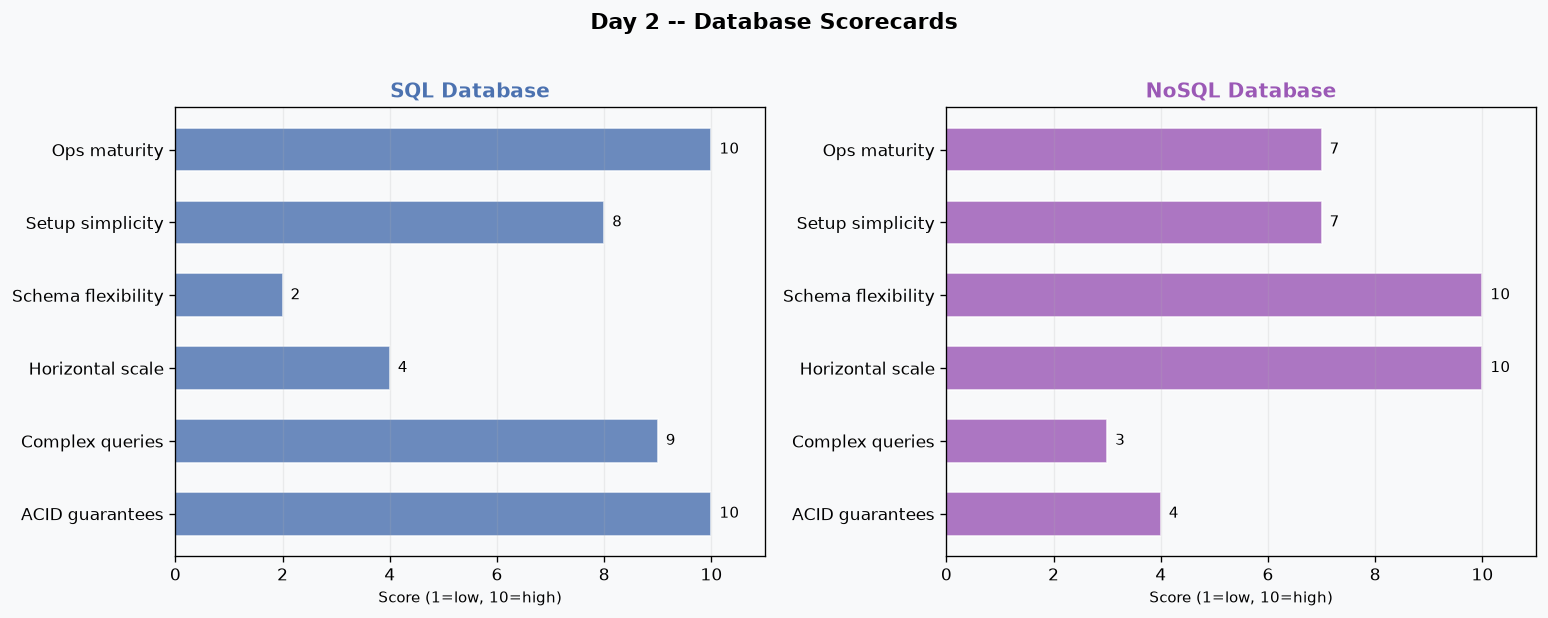

Day 2 complete.
Next: Day 3 -- Vertical Scaling vs Horizontal Scaling


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor(C_GRAY)

for ax, (title, props, color) in zip(axes, [
    ('SQL Database', [
        ('ACID guarantees',    10),
        ('Complex queries',     9),
        ('Horizontal scale',    4),
        ('Schema flexibility',  2),
        ('Setup simplicity',    8),
        ('Ops maturity',       10),
    ], C_BLUE),
    ('NoSQL Database', [
        ('ACID guarantees',    4),
        ('Complex queries',    3),
        ('Horizontal scale',  10),
        ('Schema flexibility',10),
        ('Setup simplicity',   7),
        ('Ops maturity',       7),
    ], C_PURPLE),
]):
    labels = [p[0] for p in props]
    vals   = [p[1] for p in props]
    y_pos  = np.arange(len(labels))
    bars   = ax.barh(y_pos, vals, color=color, alpha=0.82,
                     edgecolor='white', height=0.6)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=10)
    ax.set_xlim(0, 11)
    ax.set_xlabel('Score (1=low, 10=high)', fontsize=9)
    ax.set_title(title, fontsize=12, fontweight='bold', color=color)
    ax.grid(axis='x', alpha=0.2); ax.set_facecolor(C_GRAY)
    for bar, val in zip(bars, vals):
        ax.text(val + 0.15, bar.get_y() + bar.get_height()/2,
                str(val), va='center', fontsize=9)

plt.suptitle('Day 2 -- Database Scorecards', fontsize=13,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/tmp/sd_day2_scorecard.png', dpi=130, bbox_inches='tight')
plt.show()

print("Day 2 complete.")
print("Next: Day 3 -- Vertical Scaling vs Horizontal Scaling")


### What this scorecard shows
The same six-dimension scorecard as Day 1, now applied to **SQL vs NoSQL** side by side.

- **SQL**: high on ACID, complex queries, and maturity. Low on horizontal scale and schema flexibility.
- **NoSQL**: mirror profile -- high on scale and flexibility, lower on query power and consistency.

**Interview strategy**: walk through the dimensions that matter for the problem (consistency? write volume? schema stability?) before naming a product.


### What these charts show
A direct visualisation of **resource contention** -- what happens inside the CPU when two tiers share a machine.

- **Left chart**: web CPU and DB CPU add up to a shared budget. At 50% traffic the machine saturates. Neither tier is at fault -- they share a ceiling.
- **Right chart**: with separated tiers, each machine has its own 0-100% axis. The web server hits its ceiling at ~91% traffic; the DB machine is still at ~45%. You can add a second web server without touching the database at all.

**Key number**: separation roughly doubles the traffic you can handle before any machine saturates, for the cost of one extra server.


## AWS Production Notes

> Based on the AWS Well-Architected Framework and AWS official documentation.

---

### Critical Corrections

| Claim in This Notebook | Correction |
|---|---|
| 'Single Postgres maxes out ~10–50 GB before complexity explodes' | **Amazon Aurora** supports up to **128 TiB** with auto-scaling. RDS for PostgreSQL supports up to 64 TiB. The 10–50 GB limit applies only to self-managed single-node Postgres — state this explicitly. |
| SQL scale direction: 'Vertical + read replicas' (fixed property) | Aurora scales reads horizontally to **15 replicas** with automatic load balancing. Aurora Global Database spans 5 regions. Aurora Serverless v2 scales compute horizontally. SQL = vertical-only is incorrect for Aurora. |
| 'NoSQL transactions: Eventual / tunable' | **DynamoDB has supported full ACID transactions since 2018** via `TransactWriteItems` and `TransactGetItems`. Describing NoSQL as incapable of transactions causes engineers to incorrectly reject DynamoDB for financial systems. |

---

### AWS Database Service Mapping

| Generic Technology | AWS Managed Service | Key Differentiator |
|---|---|---|
| MySQL | **Amazon RDS for MySQL**, **Amazon Aurora (MySQL)** | Aurora: 128 TiB, 15 replicas, 6-copy storage across 3 AZs |
| PostgreSQL | **Amazon RDS for PostgreSQL**, **Amazon Aurora (PostgreSQL)** | Aurora Limitless for transparent horizontal sharding (see Day 10) |
| MongoDB | **Amazon DocumentDB** | MongoDB-compatible API; fully managed |
| Cassandra | **Amazon Keyspaces** | Serverless; Cassandra CQL-compatible |
| Redis | **Amazon ElastiCache for Valkey / Redis** | Multi-AZ, Global Datastore; Valkey is AWS's preferred OSS engine since 2024 |
| DynamoDB | **Amazon DynamoDB** | Serverless; ACID transactions; Global Tables; DAX for microsecond reads |
| Neo4j / graph | **Amazon Neptune** | Property graph + RDF; serverless option |
| Elasticsearch | **Amazon OpenSearch Service** | Full-text search; k-NN vector search |
| Time-series | **Amazon Timestream** | Built-in time-series query functions; much cheaper than RDS for telemetry |
| OLAP / data warehouse | **Amazon Redshift** | Separate transactional from analytical workloads |

---

### Purpose-Built Database Decision Tree (Well-Architected PERF 7)

```
1. Key-value / simple document access pattern?      → DynamoDB
2. Primarily reads, microsecond latency needed?     → DAX (DynamoDB) or ElastiCache
3. Full-text search required?                       → Amazon OpenSearch Service
4. Graph of relationships?                          → Amazon Neptune
5. Time-series data?                                → Amazon Timestream
6. Relational with complex JOINs?                   → Aurora or RDS
7. OLAP analytics / BI queries?                     → Amazon Redshift
```

---

### Security Requirements for the Database Tier

- Place the database in **private subnets** with no internet gateway route
- Configure **Security Groups**: DB port (e.g. 5432) ingress **only from the app tier's Security Group ID** — not 0.0.0.0/0
- Enable **Multi-AZ** for all production RDS/Aurora instances
- Enable **encryption at rest** via AWS KMS **at creation time** — cannot be added after
- Use **IAM database authentication** instead of static username/password (RDS/Aurora)
- Store credentials in **AWS Secrets Manager** with automatic rotation
- Add **Amazon RDS Proxy** between app and DB to pool connections (prevents hitting `max_connections`)

---

### Key CloudWatch Metrics

| Metric | Namespace | Why It Matters |
|---|---|---|
| `DatabaseConnections` | AWS/RDS | Alarm when > 80% of the instance class limit |
| `ReadLatency` | AWS/RDS | Alarm at > 20ms p99 for OLTP workloads |
| `WriteLatency` | AWS/RDS | Watch during peak writes |
| `FreeStorageSpace` | AWS/RDS | Alert before storage fills (Aurora auto-grows; RDS does not by default) |
| `ConsumedReadCapacityUnits` | AWS/DynamoDB | Know when approaching provisioned limit |

---

### Well-Architected Checklist

- [ ] **SEC 7** — Encryption at rest enabled at DB creation (KMS)
- [ ] **SEC 8** — TLS in transit enforced for all DB connections
- [ ] **REL 9** — Multi-AZ enabled; RDS automated backups with 7–35 day retention
- [ ] **PERF 7** — Use purpose-built database for the access pattern (don't force everything into RDS)
- [ ] **COST 6** — Use Aurora Serverless v2 for variable workloads; on-demand DynamoDB for unpredictable traffic
